In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
scaler = StandardScaler()
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X_scaled = scaler.fit_transform(X)
print(f'Mean: {X_scaled.mean(axis=0)}')
print(f'Standard Deviation: {X_scaled.std(axis=0)}')

Mean: [-2.13162821e-16 -1.46549439e-16]
Standard Deviation: [1. 1.]


In [ ]:
print(type(X), type(X_scaled))

<class 'pandas.core.frame.DataFrame'> <class 'numpy.ndarray'>


In [ ]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_scaled)

inertia = kmeans.inertia_
print(f'Inertia: {inertia}')

Inertia: 157.70400815035939


In [ ]:
k = 10
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_scaled)

inertia = kmeans.inertia_
print(f'Inertia: {inertia}')

Inertia: 30.05932269404222


In [ ]:
# Thử phân bộ dữ liệu thành 5 cụm
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_scaled)

inertia = kmeans.inertia_
print(f'Inertia: {inertia}')

Inertia: 65.56840815571681


In [ ]:
labels = kmeans.labels_
print(labels)
centers = kmeans.cluster_centers_
print(centers)

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]
[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


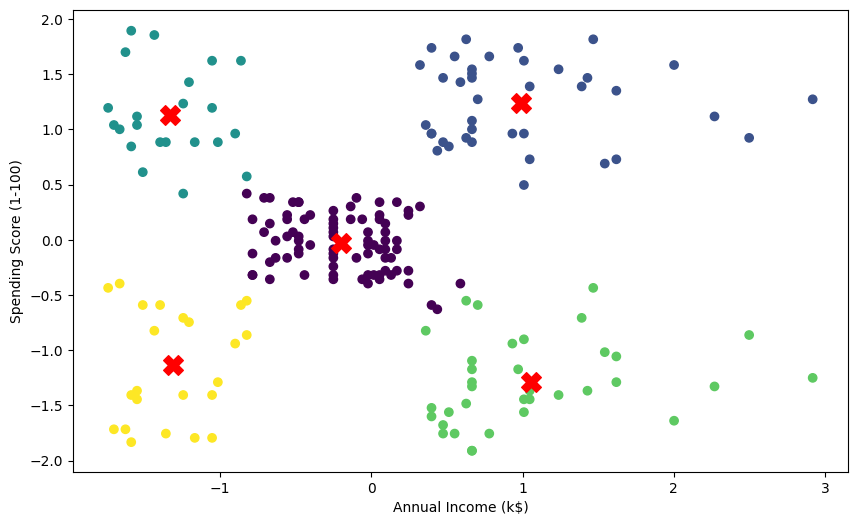

In [ ]:
# Chọn k = 5 => Trực quan hóa các cụm
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans.labels_, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()


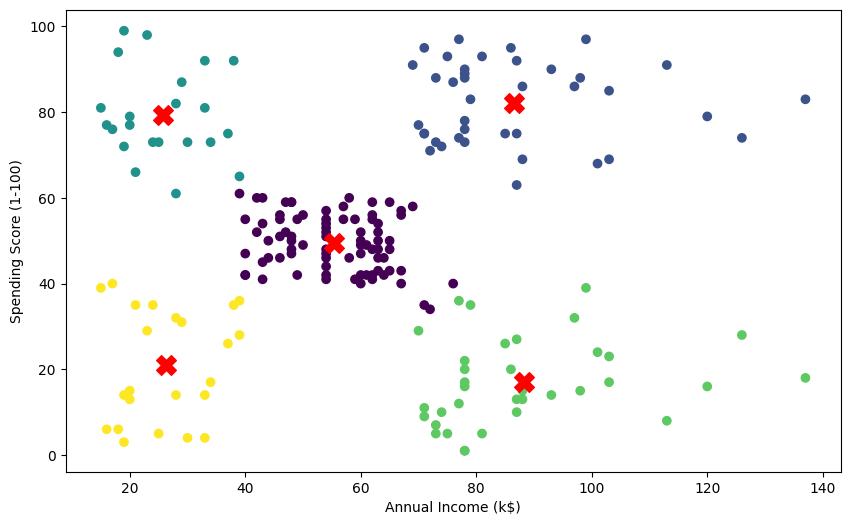

In [ ]:
unscaled_centers = scaler.inverse_transform(centers)
plt.figure(figsize=(10, 6))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=kmeans.labels_, cmap='viridis')
plt.scatter(unscaled_centers[:, 0], unscaled_centers[:, 1], c='red', marker='X', s=200)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

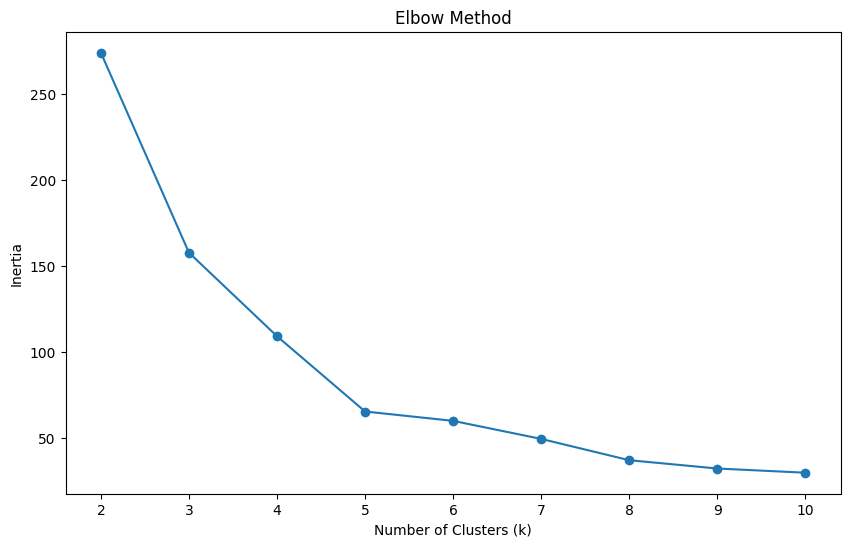

In [ ]:
k_values = range(2, 11)
inertia_values = []
# Tính các giá trị inertia
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia_values, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

Text(0, 0.5, 'Silhouette Score')

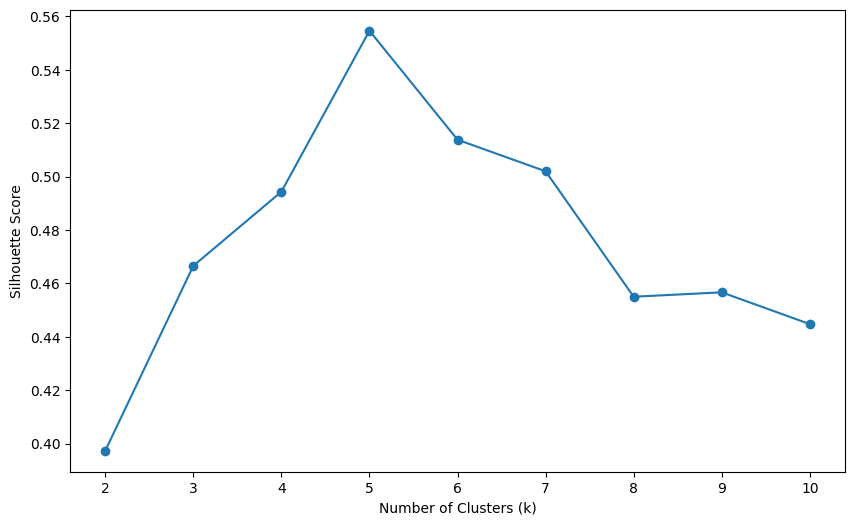

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)

plt.figure(figsize=(10, 6))
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

In [ ]:
from sklearn.preprocessing import LabelEncoder
# mã hóa giới tính
label_encoder = LabelEncoder()
df['Genre'] = label_encoder.fit_transform(df['Genre'])
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [ ]:
scaler = StandardScaler()
X = df[['Annual Income (k$)', 'Spending Score (1-100)', 'Genre', 'Age']]
X_scaled = scaler.fit_transform(X)

In [ ]:
print(f'Mean: {X_scaled.mean(axis=0)}')
print(f'Standard Deviation: {X_scaled.std(axis=0)}')

Mean: [-2.13162821e-16 -1.46549439e-16  3.10862447e-17 -1.02140518e-16]
Standard Deviation: [1. 1. 1. 1.]


In [ ]:
# Dùng 2 biện pháp Elbow và Silouhete để tìm k tối ưu
k_values = range(2, 21)
silhouette_scores = []
inertia_values = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)
    inertia_values.append(kmeans.inertia_)

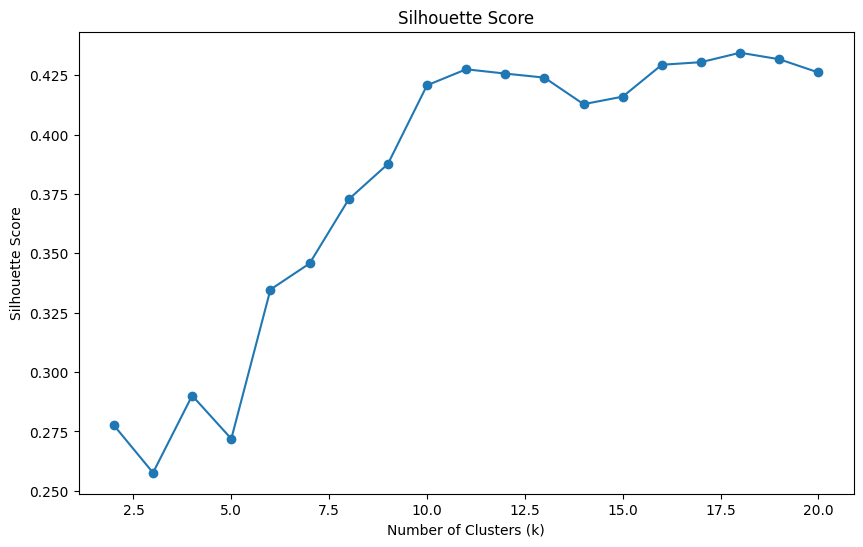

In [ ]:
# Vẽ biểu đồ silhouette
plt.figure(figsize=(10, 6))
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.show()

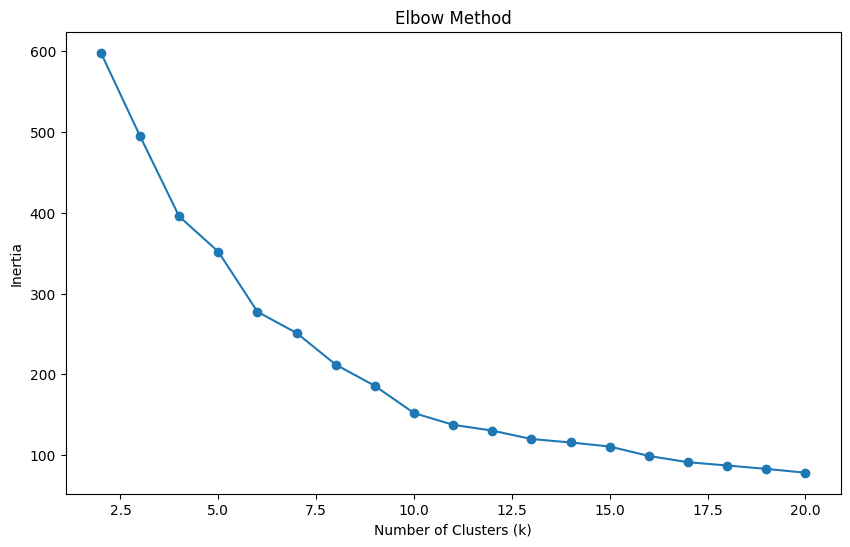

In [ ]:
# Vẽ biểu đồ Elbow
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia_values, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [ ]:
!pip install kneed

from kneed import KneeLocator
kl = KneeLocator(k_values, inertia_values, curve='convex', direction='decreasing')
print(kl.elbow)

10


In [ ]:
from sklearn.datasets import load_wine
wine = load_wine()
print(type(X))

<class 'sklearn.utils._bunch.Bunch'>


In [ ]:
X = wine.data
df_wine = pd.DataFrame(X, columns=wine.feature_names)
df_wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [ ]:
# BTVN: Chuẩn hóa bộ dữ liệu, tìm k tối ưu (Elbow + Kneed và Silouhette)